In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("D:\\EDA\\eda\\rawdata\\LARPDatabase.csv")

In [ ]:
data.columns

Index(['Unnamed: 0', 'MANAGEMENT', 'VESSEL', 'REF NO', 'OCCURRENCE DATE',
       'Status', 'AREA OF CONCERN', 'DESCRIPTION', 'IMMEDIATE ACTION TAKEN',
       'Category', 'WORK EQUIPMENT', 'LARP PROCEDURE', 'LARP SAFETY DEVICE',
       'WORK ENVIRONMENT', 'HOUSE KEEPING', 'PERMIT TO WORK', 'LARP PPE',
       'WORK POSITION', 'REPORTED BY', 'CLOSURE REMARK', 'CLOSURE DATE',
       'CLOSED BY'],
      dtype='str')

In [ ]:
data.describe()

,Unnamed: 0
count,61073.000000
mean,68252.297971
std,36322.219302
min,0.000000
25%,30699.000000
50%,77346.000000
75%,97513.000000
max,125828.000000


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 61073 entries, 0 to 61072
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Unnamed: 0              61073 non-null  int64
 1   MANAGEMENT              60107 non-null  str  
 2   VESSEL                  60107 non-null  str  
 3   REF NO                  61073 non-null  str  
 4   OCCURRENCE DATE         61073 non-null  str  
 5   Status                  61073 non-null  str  
 6   AREA OF CONCERN         39927 non-null  str  
 7   DESCRIPTION             61056 non-null  str  
 8   IMMEDIATE ACTION TAKEN  53317 non-null  str  
 9   Category                61073 non-null  str  
 10  WORK EQUIPMENT          6609 non-null   str  
 11  LARP PROCEDURE          26692 non-null  str  
 12  LARP SAFETY DEVICE      6714 non-null   str  
 13  WORK ENVIRONMENT        4417 non-null   str  
 14  HOUSE KEEPING           6476 non-null   str  
 15  PERMIT TO WORK          671 no

In [ ]:
data.drop(columns=["Unnamed: 0"], inplace=True)

In [7]:
data["OCCURRENCE DATE"] = pd.to_datetime(data["OCCURRENCE DATE"], errors="coerce")
data["CLOSURE DATE"] = pd.to_datetime(data["CLOSURE DATE"], errors="coerce")

In [8]:
data.isnull().sum().sort_values(ascending=False)

PERMIT TO WORK            60402
WORK ENVIRONMENT          56656
CLOSURE REMARK            55472
CLOSED BY                 55467
CLOSURE DATE              55466
HOUSE KEEPING             54597
WORK EQUIPMENT            54464
LARP SAFETY DEVICE        54359
WORK POSITION             53386
LARP PPE                  52774
LARP PROCEDURE            34381
AREA OF CONCERN           21146
REPORTED BY                8959
IMMEDIATE ACTION TAKEN     7756
MANAGEMENT                  966
VESSEL                      966
DESCRIPTION                  17
Status                        0
OCCURRENCE DATE               0
REF NO                        0
Category                      0
dtype: int64

In [9]:
threshold = 0.7 * len(data)
data = data.dropna(thresh=threshold, axis=1)

In [10]:
data["MANAGEMENT"] = data["MANAGEMENT"].fillna("Unknown")
data["VESSEL"] = data["VESSEL"].fillna("Unknown")

In [11]:
data.fillna({
    "MANAGEMENT": "Unknown",
    "VESSEL": "Unknown"
}, inplace=True)

,MANAGEMENT,VESSEL,REF NO,OCCURRENCE DATE,Status,DESCRIPTION,IMMEDIATE ACTION TAKEN,Category,REPORTED BY
0,SMPL - Chennai,NANYANG STAR,LR/NAST/2018/98,2018-04-22 03:05:14,Accepted,Personnel Entering Battery room without infor...,Dangers of working alone without informing OOW...,Unsafe act,Arun Kumar Moorthy
1,SMPL - Chennai,DEE4 BIRCH,LR/FRHA/2018/152,2018-08-18 09:21:47,Accepted,EXPIRED FOOD IN ECR WAS FOUND BEING USED. IMME...,NaN,Safe act,NaN
2,SMPL - Chennai,NANYANG STAR,LR/NAST/2018/153,2018-05-20 08:35:46,Accepted,during drill found SCBA bottles pressure less ...,informed the person incharge and immediately h...,Unsafe act,Suresh Velayutham
3,SMPL - Chennai,VELOS SAPPHIRE,LR/GRVIC/2015/106,2015-12-07 09:54:27,Accepted,50 ltrs gear oil in half cut drum left open on...,Shifted properly,Unsafe act,NaN
4,SMSL - Singapore,BENFICA,LR/BNFC/2018/3,2018-01-16 10:45:21,Accepted,Deck crew properly secured the hydroblast mach...,NaN,Safe act,NaN
...,...,...,...,...,...,...,...,...,...
61068,SMSL - Singapore,BULK HOLLAND,LR/BUHD/2018/126,2018-12-28 13:50:04,Accepted,one crew open the paint store room to get some...,one crew stop him and advice to ventilate it f...,Unsafe act,NaN
61069,SMPL - Chennai,GAS STELLA,LR/STGS/2018/81,2018-09-11 21:35:08,Accepted,While mooring operation at Inchon winch gear s...,Immediately mooring winch was stopped and safe...,Unsafe act,Shashi Kant Singh
61070,SMPL - Chennai,APL FLORIDA,LR/AFLO/2019/85,2019-08-13 04:03:58,Accepted,it was observed that while opening Main engine...,"stopped the person immediately, released the p...",Unsafe act,Rajesh Sugumar
61071,SMPL - Chennai,DEE4 CEDAR,LR/ORST/2018/283,2018-10-14 06:57:36,Accepted,when carrying out hydroblasting on main deck i...,Immediately informed hod and and explained the...,Unsafe act,Aditya Kotwal


In [ ]:
data = data.fillna({
    "MANAGEMENT": "Unknown",
    "VESSEL": "Unknown"
})

In [13]:
data["MANAGEMENT"] = data["MANAGEMENT"].fillna("Unknown")
data["VESSEL"] = data["VESSEL"].fillna("Unknown")

In [14]:
data.shape
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 61073 entries, 0 to 61072
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   MANAGEMENT              61073 non-null  str           
 1   VESSEL                  61073 non-null  str           
 2   REF NO                  61073 non-null  str           
 3   OCCURRENCE DATE         61073 non-null  datetime64[us]
 4   Status                  61073 non-null  str           
 5   DESCRIPTION             61056 non-null  str           
 6   IMMEDIATE ACTION TAKEN  53317 non-null  str           
 7   Category                61073 non-null  str           
 8   REPORTED BY             52114 non-null  str           
dtypes: datetime64[us](1), str(8)
memory usage: 4.2 MB


,OCCURRENCE DATE
count,61073
mean,2018-05-08 22:45:31.214301
min,2010-09-21 10:30:15
25%,2017-07-28 06:35:56
50%,2018-07-30 16:49:22
75%,2019-05-13 17:22:11
max,2019-12-31 22:07:16


In [15]:
data.isnull().sum().sort_values(ascending=False)

REPORTED BY               8959
IMMEDIATE ACTION TAKEN    7756
DESCRIPTION                 17
MANAGEMENT                   0
VESSEL                       0
Status                       0
OCCURRENCE DATE              0
REF NO                       0
Category                     0
dtype: int64

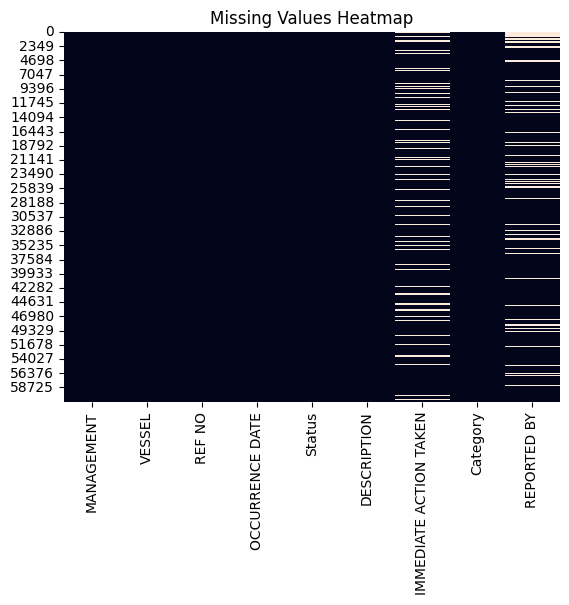

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
data["MANAGEMENT"] = data["MANAGEMENT"].fillna("Unknown")
data["VESSEL"] = data["VESSEL"].fillna("Unknown")


In [ ]:
data.columns

Index(['MANAGEMENT', 'VESSEL', 'REF NO', 'OCCURRENCE DATE', 'Status',
       'DESCRIPTION', 'IMMEDIATE ACTION TAKEN', 'Category', 'REPORTED BY'],
      dtype='str')

In [ ]:
data.isnull().sum()

MANAGEMENT                   0
VESSEL                       0
REF NO                       0
OCCURRENCE DATE              0
Status                       0
DESCRIPTION                 17
IMMEDIATE ACTION TAKEN    7756
Category                     0
REPORTED BY               8959
dtype: int64

In [ ]:
data = data.dropna(subset=['DESCRIPTION'])


data['IMMEDIATE ACTION TAKEN'] = data['IMMEDIATE ACTION TAKEN'].fillna('Not Provided')
data['REPORTED BY'] = data['REPORTED BY'].fillna('Unknown')

In [ ]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
data['occurrence_date'] = pd.to_datetime(data['occurrence_date'], errors='coerce')

In [ ]:
data.info()

<class 'pandas.DataFrame'>
Index: 61056 entries, 0 to 61072
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   management              61056 non-null  str           
 1   vessel                  61056 non-null  str           
 2   ref_no                  61056 non-null  str           
 3   occurrence_date         61056 non-null  datetime64[us]
 4   status                  61056 non-null  str           
 5   description             61056 non-null  str           
 6   immediate_action_taken  61056 non-null  str           
 7   category                61056 non-null  str           
 8   reported_by             61056 non-null  str           
dtypes: datetime64[us](1), str(8)
memory usage: 4.7 MB


In [ ]:
data = data.drop_duplicates()

In [ ]:
data['category'].value_counts()

category
Unsafe act    48470
Safe act      12586
Name: count, dtype: int64

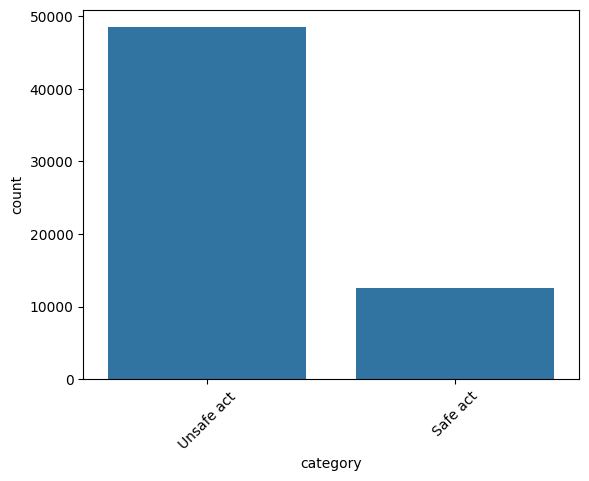

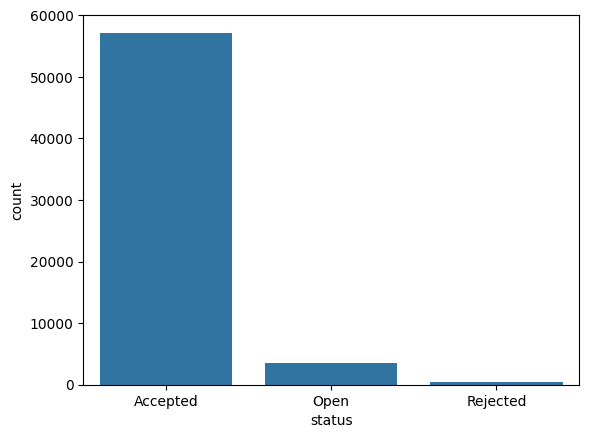

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Category plot
sns.countplot(x='category', data=data)
plt.xticks(rotation=45)
plt.show()

# Status plot
sns.countplot(x='status', data=data)
plt.show()

In [ ]:
data.columns

Index(['management', 'vessel', 'ref_no', 'occurrence_date', 'status',
       'description', 'immediate_action_taken', 'category', 'reported_by'],
      dtype='str')

In [ ]:
data['management'].value_counts()

management
SMPL - Chennai      42366
SMSL - Singapore     9067
SNSPL - Pune         5029
SOS - Kochi          3628
Unknown               966
Name: count, dtype: int64

In [29]:
pd.crosstab(data['vessel'], data['category'])

category,Safe act,Unsafe act
vessel,,
ACE SPAIN,14,90
ADITYA,33,236
AFRICAN SPOONBILL,123,28
AFRICAN TURACO,18,53
AL-BETROLEYA,36,242
...,...,...
WESTMINSTER,0,1
X-PRESS MONTE CERVINO,10,36
X-PRESS TAJUMULCO,5,15


In [30]:
pd.crosstab(data['status'], data['category'])

category,Safe act,Unsafe act
status,,
Accepted,11295,45874
Open,1144,2373
Rejected,147,223


In [31]:
pd.crosstab(data['management'], data['status'])

status,Accepted,Open,Rejected
management,,,
SMPL - Chennai,40047,2090,229
SMSL - Singapore,8937,21,109
SNSPL - Pune,5010,11,8
SOS - Kochi,3175,429,24
Unknown,0,966,0


In [ ]:
data['month'] = data['occurrence_date'].dt.month

data['month'].value_counts().sort_index()

month
1     3858
2     4126
3     4403
4     4556
5     4944
6     4795
7     5163
8     5416
9     5504
10    5655
11    6703
12    5933
Name: count, dtype: int64

In [ ]:
data['year'] = data['occurrence_date'].dt.year

data['year'].value_counts().sort_index()

year
2010        2
2011        2
2012       15
2013        1
2014        3
2015     3219
2016     6993
2017    11151
2018    16757
2019    22913
Name: count, dtype: int64

In [ ]:
data['reported_by'].value_counts().head(10)

reported_by
Unknown                            8957
Neil Perez Galvadores               283
Amit Kumar                          136
Sumit Kumar                         128
Abhishek Kumar                      118
Cyril Angelo Pimentel Patricio      117
John Lerry Leodones Pajarillaga     114
Anurag Sharma                       113
Susai Antony Raj Arockia Samy        94
Rahul Prasad                         92
Name: count, dtype: int64

In [ ]:
data['desc_length'] = data['description'].str.len()

data['desc_length'].describe()

count    61056.000000
mean       105.180212
std         64.546032
min          1.000000
25%         68.000000
50%         90.000000
75%        125.000000
max       2744.000000
Name: desc_length, dtype: float64

In [ ]:
data['desc_length'] = data['description'].str.len()

data['desc_length'].describe()

count    61056.000000
mean       105.180212
std         64.546032
min          1.000000
25%         68.000000
50%         90.000000
75%        125.000000
max       2744.000000
Name: desc_length, dtype: float64

In [37]:
from collections import Counter

words = " ".join(data['description']).split()
Counter(words).most_common(10)

[('the', 46989),
 ('of', 23512),
 ('was', 21867),
 ('crew', 18748),
 ('to', 17394),
 ('in', 16855),
 ('and', 16631),
 ('found', 15839),
 ('on', 13790),
 ('not', 10743)]

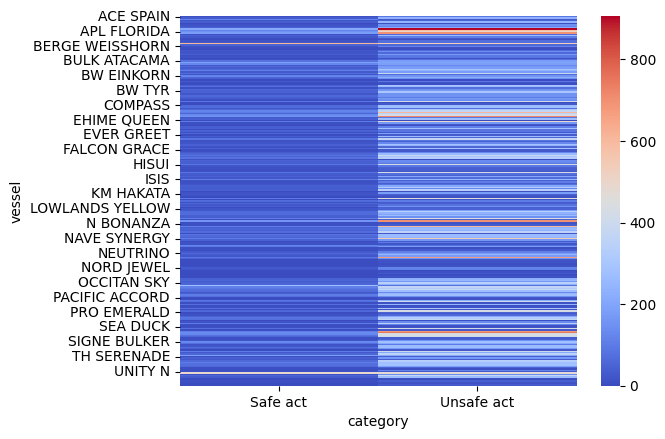

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = pd.crosstab(data['vessel'], data['category'])

sns.heatmap(pivot, cmap='coolwarm')
plt.show()

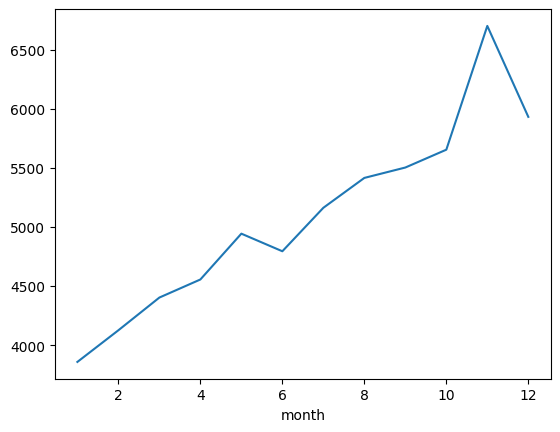

In [39]:
data.groupby('month').size().plot(kind='line')
plt.show()

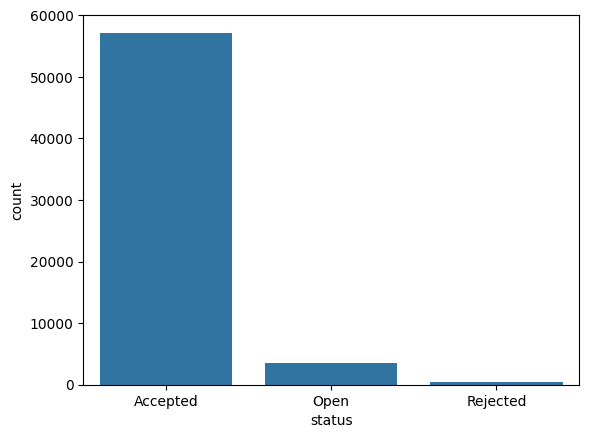

In [40]:
sns.countplot(x='status', data=data)
plt.show()

In [41]:
data.nunique()
data['management'].nunique()
data['vessel'].nunique()
data['category'].nunique()

data['status'].nunique()

3

In [42]:
data['management'].value_counts().head(5)

management
SMPL - Chennai      42366
SMSL - Singapore     9067
SNSPL - Pune         5029
SOS - Kochi          3628
Unknown               966
Name: count, dtype: int64

In [43]:
data['vessel'].value_counts().head(5)


vessel
BENFICA        1142
APL ANTWERP    1115
Unknown         966
SEROJA ENAM     885
DEE4 CEDAR      884
Name: count, dtype: int64

In [44]:

data['category'].value_counts().head(5)


category
Unsafe act    48470
Safe act      12586
Name: count, dtype: int64

In [45]:

data['status'].value_counts().head(5)


status
Accepted    57169
Open         3517
Rejected      370
Name: count, dtype: int64

In [46]:


data['reported_by'].value_counts().head(5)

reported_by
Unknown                  8957
Neil Perez Galvadores     283
Amit Kumar                136
Sumit Kumar               128
Abhishek Kumar            118
Name: count, dtype: int64

In [47]:
data['vessel'].value_counts().tail(5)

vessel
NORD NEPTUNE     3
EHIME QUEEN      2
PACIFIC SOUTH    2
NORD QUEBEC      2
WESTMINSTER      1
Name: count, dtype: int64

In [48]:
data['management'].value_counts().tail(5)

management
SMPL - Chennai      42366
SMSL - Singapore     9067
SNSPL - Pune         5029
SOS - Kochi          3628
Unknown               966
Name: count, dtype: int64

In [49]:
data['category'].value_counts().tail(5)

category
Unsafe act    48470
Safe act      12586
Name: count, dtype: int64

In [50]:
data['status'].value_counts().tail(5)

status
Accepted    57169
Open         3517
Rejected      370
Name: count, dtype: int64

In [51]:
data['reported_by'].value_counts().tail(5)

reported_by
Mohan Ram Khilery                1
Santosh Kumar Singh              1
Hemant Namdev Mandvikar          1
Vignesh Sanjeev                  1
Tomas Leslie Catarina Pereira    1
Name: count, dtype: int64

In [52]:
(data.isnull().sum()/len(data))*100

management                0.0
vessel                    0.0
ref_no                    0.0
occurrence_date           0.0
status                    0.0
description               0.0
immediate_action_taken    0.0
category                  0.0
reported_by               0.0
month                     0.0
year                      0.0
desc_length               0.0
dtype: float64

In [53]:
data.duplicated().sum()

np.int64(0)

In [54]:
data[data.duplicated()]

,management,vessel,ref_no,occurrence_date,status,description,immediate_action_taken,category,reported_by,month,year,desc_length


In [55]:
data.drop_duplicates(inplace=True)

In [56]:
data['year'] = data['occurrence_date'].dt.year

In [57]:
data['desc_length'] = data['description'].str.len()
data['desc_length'].describe()

count    61056.000000
mean       105.180212
std         64.546032
min          1.000000
25%         68.000000
50%         90.000000
75%        125.000000
max       2744.000000
Name: desc_length, dtype: float64

In [58]:
data['word_count'] = data['description'].str.split().str.len()
data['word_count'].describe()

count    61056.000000
mean        17.798103
std         11.000803
min          0.000000
25%         11.000000
50%         15.000000
75%         21.000000
max        412.000000
Name: word_count, dtype: float64

In [59]:
from collections import Counter
Counter(" ".join(data['description']).split()).most_common(20)

[('the', 46989),
 ('of', 23512),
 ('was', 21867),
 ('crew', 18748),
 ('to', 17394),
 ('in', 16855),
 ('and', 16631),
 ('found', 15839),
 ('on', 13790),
 ('not', 10743),
 ('member', 10574),
 ('one', 9307),
 ('THE', 8218),
 ('while', 7476),
 ('without', 7124),
 ('for', 7019),
 ('with', 6971),
 ('Found', 6418),
 ('deck', 6414),
 ('During', 6400)]

In [60]:
data['description'].str.contains('error', case=False).sum()

np.int64(22)

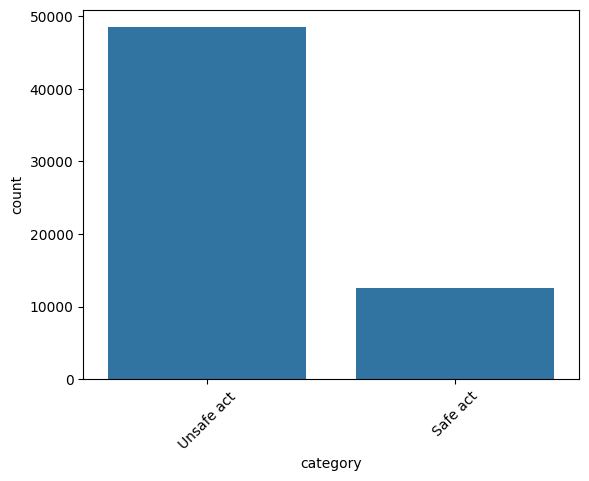

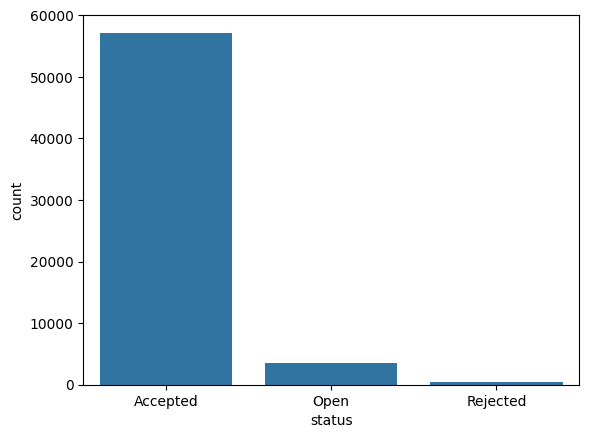

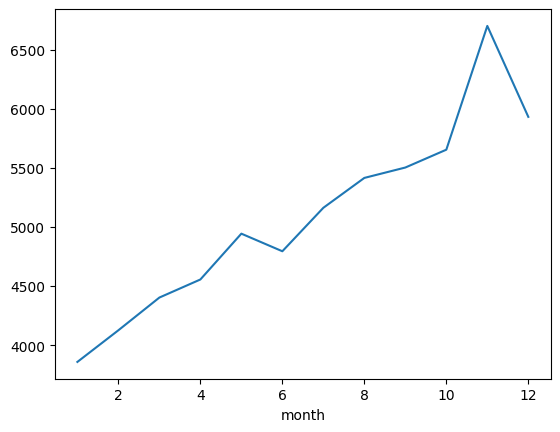

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=data)
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='status', data=data)
plt.show()

data.groupby('month').size().plot()
plt.show()